In [6]:
from langgraph.graph import StateGraph,START,END
from typing import  TypedDict,Literal

In [7]:
class QuadraticState(TypedDict):
    a:float
    b:float
    c:float

    equation:str
    discriminant:float
    result:str

In [8]:
def show_equation(state:QuadraticState):
    equation= f'{state["a"]}x2+ {state["b"]}x + {state["c"]} = 0'
    

    return {'equation':equation}

In [9]:
def dicriminant(state:QuadraticState):
    a=state['a']
    b=state['b']
    c=state['c']

    discriminant = b**2 - 4*a*c

    return {'discriminant':discriminant}

def real_root(state:QuadraticState):
    discriminant = state['discriminant']

    root1= (-state['b'] + discriminant**0.5)/(2*state['a'])
    root2= (-state['b'] - discriminant**0.5)/(2*state['a'])

    result = f'The roots are real and different: {root1} and {root2}'

    return {'result':result}

def complex_root(state:QuadraticState):
    result = f'no real roots exist as the discriminant is negative'
    return {'result':result}

def equal_root(state:QuadraticState):
    root = -state['b']/(2*state['a'])

    result = f'The roots are real and equal: {root}'

    return {'result':result}

In [23]:
def check_function(state:QuadraticState) -> Literal['real_root','equal_root','complex_root']:
    discriminant = state['discriminant']

    if discriminant>0:
        return 'real_root'
    elif discriminant==0:
        return 'equal_root'
    else:
        return 'complex_root'

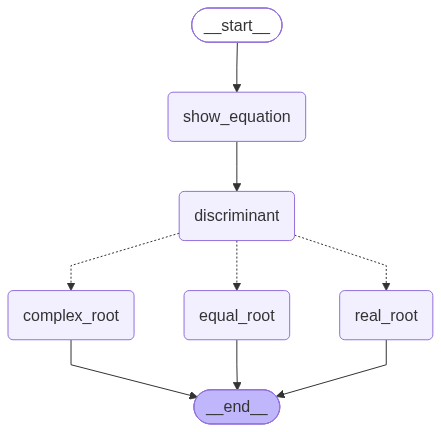

In [24]:
graph = StateGraph(QuadraticState)

graph.add_node('show_equation', show_equation)
graph.add_node('discriminant', dicriminant)

graph.add_node('real_root',real_root)
graph.add_node('complex_root',complex_root)
graph.add_node('equal_root',equal_root)
# graph.add_node('check_function',check_function )

## graph edge
graph.add_edge(START, 'show_equation')
graph.add_edge('show_equation', 'discriminant')
graph.add_conditional_edges('discriminant', check_function)

graph.add_edge('real_root', END)
graph.add_edge('equal_root', END)
graph.add_edge('complex_root', END)

workflow = graph.compile()
workflow


In [25]:
initial_state = {'a': 1, 'b': -5, 'c': 6}

output = workflow.invoke(initial_state)
output


{'a': 1,
 'b': -5,
 'c': 6,
 'equation': '1x2+ -5x + 6 = 0',
 'discriminant': 1,
 'result': 'The roots are real and different: 3.0 and 2.0'}